# 🔍 Thành viên 4 (EDA 2): Phân tích sâu về ngữ nghĩa (Text Analytics)

## 0. Đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os
import warnings
warnings.filterwarnings('ignore') 

# Cấu hình đồ thị cho Notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6) 
plt.rcParams['font.size'] = 12 
sns.set_style('whitegrid') 

# Tên nhãn và màu sắc
LABEL_NAMES = {0: 'Không tiêu cực', 1: 'Tiêu cực', 2: 'Thù ghét'} 
COLORS = ['#2ecc71', '#e67e22', '#e74c3c'] 

# Thư mục output
OUTPUT_DIR = 'eda_output' 
os.makedirs(OUTPUT_DIR, exist_ok=True) 

# ============================================================================
# 1. ĐỌC DỮ LIỆU ĐÃ TIỀN XỬ LÝ
# ============================================================================
print("=" * 60) 
print("📂 ĐỌC DỮ LIỆU") 
print("=" * 60) 

train = pd.read_csv('../data/train_clean.csv')
dev = pd.read_csv('../data/dev_clean.csv')
test = pd.read_csv('../data/test_clean.csv')

for name, df in [('Train', train), ('Dev', dev), ('Test', test)]: 
    print(f"  {name}: {df.shape[0]} samples, {df.shape[1]} columns") 

# Hiển thị thử vài dòng đầu của tập train
display(train.head())

📂 ĐỌC DỮ LIỆU
  Train: 22510 samples, 3 columns
  Dev: 2633 samples, 3 columns
  Test: 6527 samples, 3 columns


,free_text,label_id,free_text_clean
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0,em được làm fan cứng luôn rồi nè reaction quá ...
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2,đúng là bọn mắt híp lò xo thụt bên việt nam t ...
2,Đậu Văn Cường giờ giống thằng sida hơn à,0,đậu văn cường giờ giống thằng sida hơn à
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2,côn đồ cục súc vô nhân tính đề nghi vn nhà nướ...
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0,từ lý thuyết đến thực hành là cả 1 câu chuyện dài


## 1. Tạo Word Cloud cho từng loại nhãn
**Câu hỏi:** Từ nào xuất hiện nhiều nhất ở bình luận Tiêu cực/Không tiêu cực?

☁️ TẠO WORD CLOUD CHO TỪNG NHÃN
✅ Đã lưu ảnh tại: eda_output/wordcloud_label_0.png


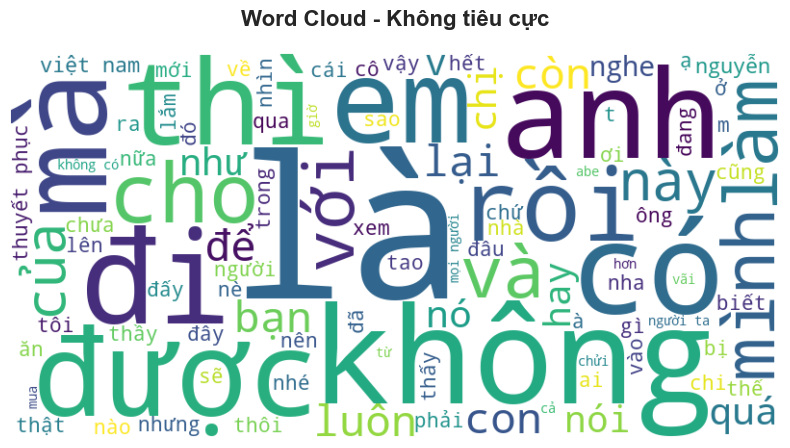

✅ Đã lưu ảnh tại: eda_output/wordcloud_label_1.png


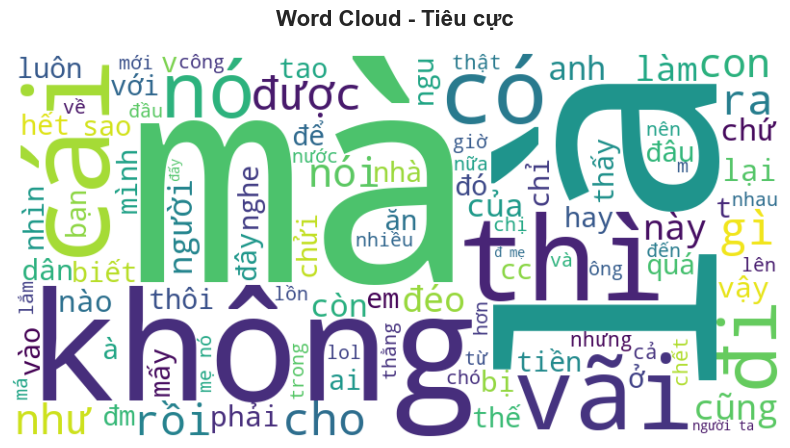

✅ Đã lưu ảnh tại: eda_output/wordcloud_label_2.png


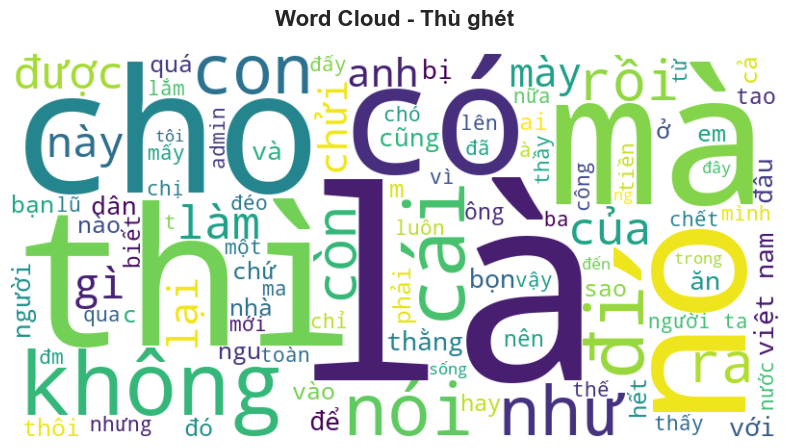

In [2]:
# Cài đặt thư viện wordcloud nếu chưa có: !pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("=" * 60)
print("☁️ TẠO WORD CLOUD CHO TỪNG NHÃN")
print("=" * 60)

# Duyệt qua từng nhãn: 0 (Không tiêu cực), 1 (Tiêu cực), 2 (Thù ghét)
for label in [0, 1, 2]: 
    # Lấy toàn bộ văn bản của nhãn hiện tại
    texts = train[train['label_id'] == label]['free_text_clean'].astype(str) 
    all_words = ' '.join(texts)
    
    # Tạo Word Cloud
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap='viridis',
                          max_words=100).generate(all_words)
    
    # Vẽ và hiển thị ảnh
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {LABEL_NAMES[label]}', fontsize=16, fontweight='bold', pad=20) 
    
    # Lưu ảnh vào thư mục eda_output
    file_path = f"{OUTPUT_DIR}/wordcloud_label_{label}.png" 
    plt.savefig(file_path, dpi=150, bbox_inches='tight')
    print(f"✅ Đã lưu ảnh tại: {file_path}")
    
    # Hiển thị ảnh trực tiếp trên notebook
    plt.show()
    plt.close()

### 💡 Nhận xét về Word Cloud và Từ vựng phổ biến

Dựa trên trực quan hóa từ 3 Word Cloud, ta có thể rút ra các nhận xét sau:

**1. Điểm chung (Vấn đề về dữ liệu):**
- Ở cả 3 nhãn, các từ có kích thước lớn nhất (xuất hiện nhiều nhất) đều là các hư từ, từ nối hoặc từ phổ biến trong tiếng Việt (Stopwords) như: **"không", "là", "mà", "thì", "có", "được", "đi", "cái"**. 
- Điều này cho thấy bước tiền xử lý dữ liệu (Preprocessing) có thể chưa loại bỏ triệt để Stopwords, làm mờ đi các đặc trưng ngữ nghĩa thực sự của từng nhãn.

**2. Đặc trưng riêng của từng nhãn:**
- **Nhãn Không tiêu cực (0):** Ngoài các stopwords, nhóm này xuất hiện nhiều đại từ xưng hô lịch sự và mang tính giao tiếp thông thường như **"anh", "em", "mình", "bạn"**. Không có sự xuất hiện của từ ngữ mang sắc thái mạnh.
- **Nhãn Tiêu cực (1):** Bắt đầu xuất hiện sự dịch chuyển trong đại từ xưng hô sang hướng kém thân thiện hơn như **"nó", "tao"**. Đồng thời, xen lẫn các stopwords là các từ mang biểu cảm mạnh, bực tức hoặc tiêu cực như **"vãi", "ngu", "chửi", "đéo"**.
- **Nhãn Thù ghét (2):** Tính công kích và miệt thị thể hiện rõ nét hơn hẳn. Mặc dù bị các stopwords che lấp một phần, nhưng ta vẫn dễ dàng nhận thấy sự xuất hiện dày đặc của các đại từ chỉ định mang tính gộp nhóm, hạ thấp như **"bọn", "thằng", "lũ", "mày"**, đi kèm với các từ chửi thề, xúc phạm nặng nề.

---

**🎯 Trả lời câu hỏi trọng tâm:** 
*(Từ nào xuất hiện nhiều nhất ở bình luận Tiêu cực/Không tiêu cực?)*

Nhìn vào kích thước chữ lớn nhất trên biểu đồ:
- **Ở bình luận Không tiêu cực:** Các từ xuất hiện nhiều nhất là **"không", "có", "là", "thì", "anh", "em"**.
- **Ở bình luận Tiêu cực:** Các từ xuất hiện nhiều nhất là **"mà", "là", "không", "thì", "có", "nó"**.

**📌 Đề xuất cải thiện (Dành cho bước tiếp theo):** 
Để Word Cloud và các phân tích N-gram phản ánh đúng "ngữ nghĩa" của sự tiêu cực/thù ghét, ta cần bổ sung một danh sách Stopwords tiếng Việt (custom stopword list) chứa các từ ("là", "mà", "thì", "có", "cái"...) để lọc lại tập `free_text_clean` trước khi đếm từ.

## 2. Thống kê Top 20 từ và N-grams phổ biến nhất theo nhãn
Vẽ biểu đồ cột ngang (Bar chart) thể hiện tần suất xuất hiện của Top 20 từ (Unigram) và Top 20 cụm 2 từ (Bigram) để xem cấu trúc cụm từ nào thường được sử dụng trong các nhãn tiêu cực/thù ghét.*

📊 TOP 20 TỪ ĐƠN (UNIGRAM) PHỔ BIẾN NHẤT THEO NHÃN
✅ Đã lưu ảnh Unigram tại: eda_output/top20_words_by_label.png


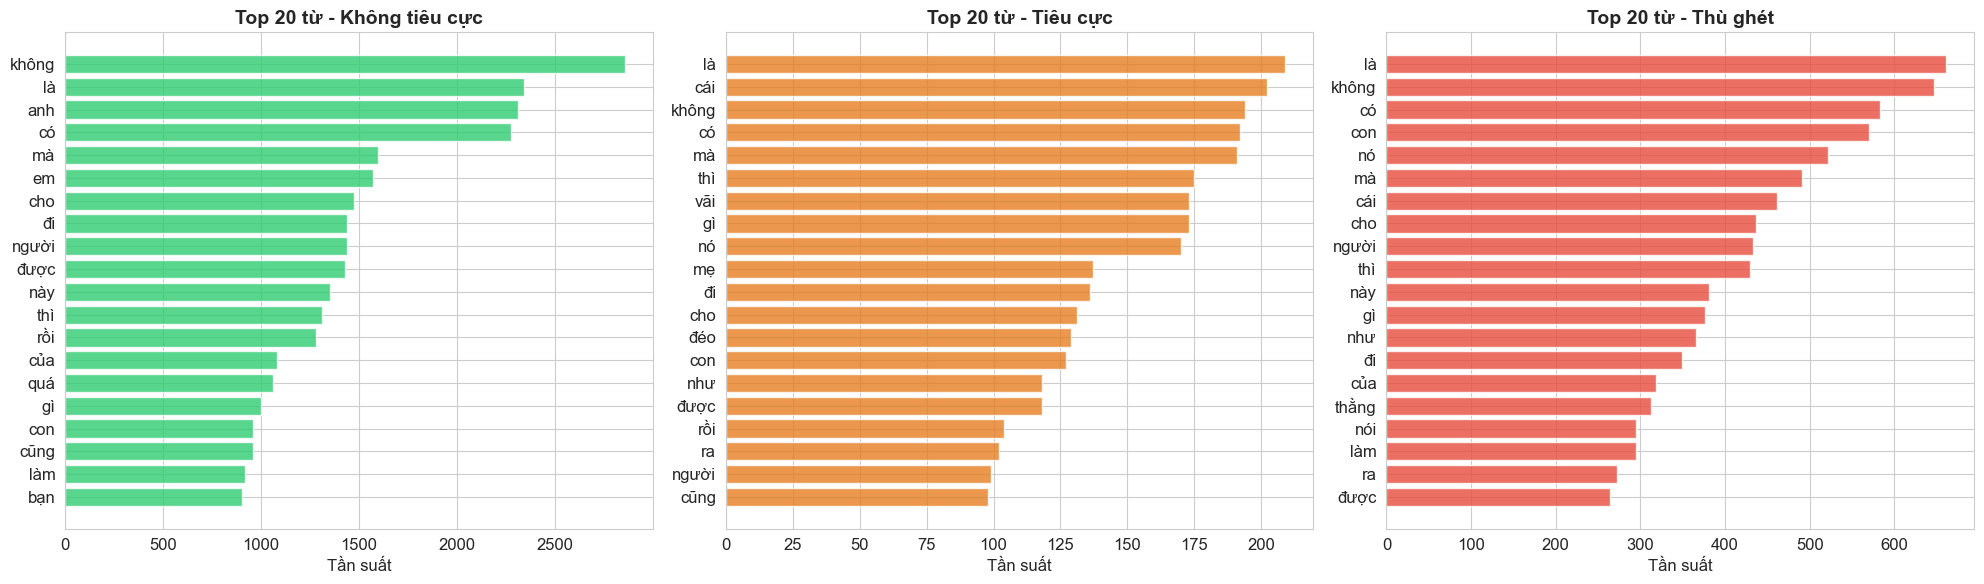

In [3]:
print("=" * 60)
print("📊 TOP 20 TỪ ĐƠN (UNIGRAM) PHỔ BIẾN NHẤT THEO NHÃN")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(20, 6)) 

for label in [0, 1, 2]: 
    # Lấy dữ liệu text theo nhãn
    texts = train[train['label_id'] == label]['free_text_clean'].astype(str) 
    all_words = ' '.join(texts).split() 
    
    # Đếm tần suất và lấy Top 20
    word_freq = Counter(all_words).most_common(20) 
    words, counts = zip(*word_freq) 
    
    # Vẽ biểu đồ Barh
    axes[label].barh(range(len(words)), counts, color=COLORS[label], alpha=0.8) 
    axes[label].set_yticks(range(len(words))) 
    axes[label].set_yticklabels(words) 
    axes[label].invert_yaxis()  # Đảo ngược trục Y để từ xuất hiện nhiều nhất nằm ở trên 
    
    axes[label].set_title(f'Top 20 từ - {LABEL_NAMES[label]}', fontweight='bold', fontsize=14) 
    axes[label].set_xlabel('Tần suất') 

plt.tight_layout() 
file_path_unigram = f'{OUTPUT_DIR}/top20_words_by_label.png' 
plt.savefig(file_path_unigram, dpi=150, bbox_inches='tight') 
print(f"✅ Đã lưu ảnh Unigram tại: {file_path_unigram}")
plt.show()
plt.close()

### 💡 Nhận xét về Top 20 từ đơn (Unigram) phổ biến

Dựa vào biểu đồ cột thể hiện Top 20 từ đơn, ta có thể rút ra các phân tích chi tiết sau:

**1. Sự áp đảo của Stopwords (Từ dừng):**
- Ở cả 3 nhãn, các vị trí dẫn đầu đều bị chiếm đóng bởi các từ nối, từ chỉ định hoặc hư từ không mang nhiều sắc thái biểu cảm (như: **"là", "không", "có", "mà", "thì", "cái"**).
- Điều này một lần nữa khẳng định sự cần thiết của việc xây dựng một bộ từ điển Stopwords tiếng Việt chuyên biệt để lọc bỏ nhiễu, giúp các mô hình Machine Learning sau này tập trung vào các từ mang ý nghĩa thực sự.

**2. Sự dịch chuyển về sắc thái ngôn ngữ qua các nhãn:**
- **Nhãn Không tiêu cực:** Dữ liệu phản ánh văn phong giao tiếp thông thường, thân thiện với sự xuất hiện của các đại từ nhân xưng lịch sự như **"anh", "em", "bạn"**.
- **Nhãn Tiêu cực:** Bắt đầu xuất hiện rõ rệt các từ ngữ mang tính chất cảm thán mạnh, bực tức hoặc chửi thề như **"vãi", "mẹ", "đéo"**. Đại từ xưng hô cũng chuyển hướng sang xuồng xã hơn với sự xuất hiện của từ **"nó"**.
- **Nhãn Thù ghét:** Các đại từ mang tính chất công kích cá nhân, miệt thị và hạ thấp người khác vươn lên các thứ hạng rất cao, tiêu biểu là **"con", "nó", "thằng"**. Đặc biệt, tần suất của "con" và "nó" lọt hẳn vào top 5 từ xuất hiện nhiều nhất của nhóm này.

**3. Tín hiệu về sự mất cân bằng dữ liệu (Data Imbalance):**
- Quan sát trục ngang (Tần suất), ta thấy thang đo của nhãn Không tiêu cực rất lớn (từ phổ biến nhất vượt mốc 2500 lần xuất hiện). Trong khi đó, nhãn Thù ghét có mốc tối đa khoảng gần 700, và nhãn Tiêu cực chỉ ở mức hơn 200.
- Sự chênh lệch khổng lồ về tần suất từ vựng này hoàn toàn khớp với biểu đồ phân bố nhãn ban đầu, tái khẳng định rằng dữ liệu đang bị mất cân bằng nghiêm trọng và nghiêng hẳn về lớp Không tiêu cực.

📊 TOP 20 CỤM 2 TỪ (BIGRAM) PHỔ BIẾN NHẤT THEO NHÃN
✅ Đã lưu ảnh Bigram tại: eda_output/top20_bigrams_by_label.png


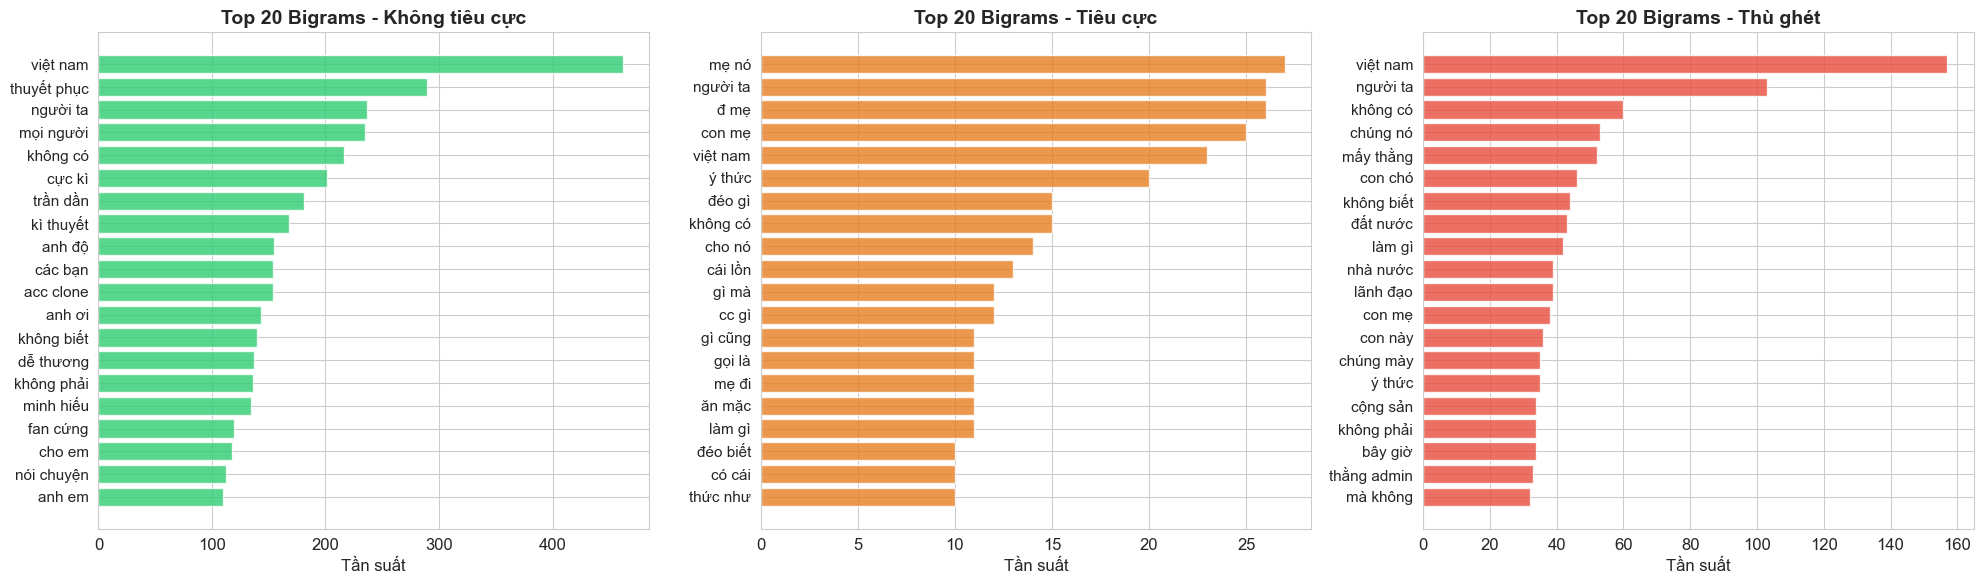

In [4]:
print("=" * 60)
print("📊 TOP 20 CỤM 2 TỪ (BIGRAM) PHỔ BIẾN NHẤT THEO NHÃN")
print("=" * 60)

def get_ngrams(texts, n=2, top_k=20): 
    """Hàm trích xuất và đếm n-gram từ tập văn bản"""
    all_ngrams = [] 
    for text in texts: 
        words = str(text).split() 
        if len(words) >= n: 
            ngrams = [' '.join(words[i:i+n]) for i in range(len(words)-n+1)] 
            all_ngrams.extend(ngrams) 
    return Counter(all_ngrams).most_common(top_k) 

fig, axes = plt.subplots(1, 3, figsize=(20, 6)) 

for label in [0, 1, 2]: 
    texts = train[train['label_id'] == label]['free_text_clean'] 
    bigrams = get_ngrams(texts, n=2, top_k=20) # Chỉnh thành top 20 theo yêu cầu 
    
    if bigrams: 
        words, counts = zip(*bigrams) 
        axes[label].barh(range(len(words)), counts, color=COLORS[label], alpha=0.8) 
        axes[label].set_yticks(range(len(words))) 
        axes[label].set_yticklabels(words, fontsize=11) 
        axes[label].invert_yaxis() 
        
    axes[label].set_title(f'Top 20 Bigrams - {LABEL_NAMES[label]}', fontweight='bold', fontsize=14) 
    axes[label].set_xlabel('Tần suất') 

plt.tight_layout() 
file_path_bigram = f'{OUTPUT_DIR}/top20_bigrams_by_label.png' 
plt.savefig(file_path_bigram, dpi=150, bbox_inches='tight') 
print(f"✅ Đã lưu ảnh Bigram tại: {file_path_bigram}")
plt.show()
plt.close()

### 💡 Nhận xét về Top 20 cụm 2 từ (Bigram) phổ biến

Việc phân tích n-gram (cụ thể là bigram) giúp ta nhìn rõ hơn ngữ cảnh và chủ đề của câu thay vì chỉ các từ đơn lẻ. Dựa vào biểu đồ, ta có các insight quan trọng sau:

**1. Nhãn Không tiêu cực (0) - Thân thiện và mang tính cộng đồng:**
- Ngữ cảnh giao tiếp rất văn minh, tích cực với các cụm từ xưng hô tôn trọng, gần gũi: **"mọi người", "các bạn", "anh em", "anh ơi", "dễ thương"**.
- Đặc biệt, dữ liệu phản ánh rõ nguồn gốc thu thập từ mạng xã hội (có thể là YouTube/Facebook/Tiktok) thông qua các cụm từ đặc trưng của văn hóa mạng/livestream như: **"fan cứng", "acc clone", "anh độ"** (có thể nhắc đến streamer Độ Mixi) hay **"thuyết phục"**. 

**2. Nhãn Tiêu cực (1) - Bức xúc, văng tục và chỉ trích hành vi:**
- Nhóm này bị thống trị bởi các cụm từ chửi thề, văng tục với tần suất rất cao (như **"mẹ nó", "đ mẹ", "con mẹ", "đéo gì", "cái lồn"**). 
- Chủ đề của các bình luận tiêu cực thường xoay quanh việc phán xét, chỉ trích hành vi, lối sống của một cá nhân nào đó, thể hiện qua các cụm từ như **"ý thức", "ăn mặc", "thức như"** (có thể là "ý thức như...").

**3. Nhãn Thù ghét (2) - Tấn công có chủ đích và yếu tố chính trị/xã hội:**
- *Tính công kích và phân biệt:* Khác với sự bực tức bộc phát ở nhãn Tiêu cực, nhãn Thù ghét cho thấy sự gộp nhóm để miệt thị nặng nề bằng các cụm đại từ: **"chúng nó", "mấy thằng", "chúng mày", "con chó", "con này"**. Nó mang tính thù hằn sâu sắc hơn.
- *Chủ đề nhạy cảm:* Điểm khác biệt lớn nhất là sự xuất hiện dày đặc của các từ khóa mang yếu tố vĩ mô, chính trị hoặc tổ chức. Người dùng ở nhóm này thường nhắm sự thù ghét vào các đối tượng cụ thể thông qua các cụm từ: **"đất nước", "nhà nước", "lãnh đạo", "cộng sản", "thằng admin"**. 

**📌 Kết luận cho việc huấn luyện mô hình:**
- Phân tích Bigram cho thấy ngữ nghĩa rõ ràng hơn hẳn Unigram (vốn bị nhiễu bởi Stopwords).
- Khi xây dựng mô hình phân loại (đặc biệt là các mô hình truyền thống như SVM, Logistic Regression hoặc Naive Bayes sử dụng TF-IDF), việc thêm đặc trưng **Bigram/Trigram là bắt buộc** để mô hình có thể bắt được các cụm từ chửi thề hoặc các từ khóa chính trị nhạy cảm, giúp phân biệt ranh giới giữa "Tiêu cực" và "Thù ghét".

## 3. Phát hiện điểm bất thường (Outliers)
Tìm kiếm các mẫu dữ liệu có độ dài bất thường (quá ngắn, quá dài) hoặc chứa quá nhiều ký tự đặc biệt/ký tự lạ để xem xét có nên loại bỏ trước khi đưa vào huấn luyện mô hình hay không.*

In [6]:
print("=" * 60)
print("🚨 PHÁT HIỆN ĐIỂM BẤT THƯỜNG (OUTLIERS)")
print("=" * 60)

# Bổ sung tạo cột word_count (số từ) nếu chưa có
if 'word_count' not in train.columns:
    train['word_count'] = train['free_text_clean'].astype(str).str.split().str.len()

# 1. Phân tích câu quá ngắn (<= 2 từ)
short_texts = train[train['word_count'] <= 2]
print(f"🔹 Số lượng câu rất ngắn (<= 2 từ): {short_texts.shape[0]} mẫu ({short_texts.shape[0]/len(train)*100:.2f}%)")
print("Ví dụ vài câu quá ngắn:")
display(short_texts[['free_text', 'free_text_clean', 'label_id']].head(5))

# 2. Phân tích câu quá dài (> 100 từ)
long_texts = train[train['word_count'] > 100]
print(f"\n🔹 Số lượng câu rất dài (> 100 từ): {long_texts.shape[0]} mẫu ({long_texts.shape[0]/len(train)*100:.2f}%)")
print("Ví dụ vài câu quá dài:")
display(long_texts[['free_text', 'word_count', 'label_id']].head(3))

# 3. Phân tích câu chứa nhiều ký tự đặc biệt/ký tự lạ
# Hàm tính tỷ lệ ký tự không phải chữ cái/số trong câu gốc (free_text)
def special_char_ratio(text):
    text = str(text)
    if len(text) == 0: return 0
    # Xóa chữ, số và khoảng trắng, giữ lại ký tự đặc biệt
    special_chars = re.sub(r'[\w\s]', '', text) 
    return len(special_chars) / len(text)

train['special_ratio'] = train['free_text'].apply(special_char_ratio)

# Lọc các câu có hơn 40% là ký tự đặc biệt
weird_texts = train[train['special_ratio'] > 0.4] 
print(f"\n🔹 Số lượng câu chứa nhiều ký tự lạ (>40% là ký tự đặc biệt): {weird_texts.shape[0]} mẫu")
if weird_texts.shape[0] > 0:
    print("Ví dụ vài câu chứa nhiều ký tự lạ:")
    display(weird_texts[['free_text', 'special_ratio', 'label_id']].head(5))
else:
    print("Không phát hiện câu nào chứa quá nhiều ký tự lạ!")

🚨 PHÁT HIỆN ĐIỂM BẤT THƯỜNG (OUTLIERS)
🔹 Số lượng câu rất ngắn (<= 2 từ): 1460 mẫu (6.49%)
Ví dụ vài câu quá ngắn:


,free_text,free_text_clean,label_id
31,chuẩn,chuẩn,0
46,xxx video 🔞,xx video,1
78,Khá khó🙂,khá khó,0
88,Maruko Linh,maruko linh,0
91,BaVi :)),bavi,0



🔹 Số lượng câu rất dài (> 100 từ): 17 mẫu (0.08%)
Ví dụ vài câu quá dài:


,free_text,word_count,label_id
1689,Tnao thiếu iot thế bạn huy minh lương. Bạn về ...,101,2
2481,Em oi ..con Linh Dai Loan no´co´nhô? lông dai´...,166,2
3334,Mình k quan tâm tới chuyện c Linda làm đẹp ra ...,110,0



🔹 Số lượng câu chứa nhiều ký tự lạ (>40% là ký tự đặc biệt): 98 mẫu
Ví dụ vài câu chứa nhiều ký tự lạ:


,free_text,special_ratio,label_id
185,:3,0.500000,0
332,@Yo Min :)))),0.461538,0
635,Yêu chị quá. ♥️♥️♥️♥️♥️,0.478261,0
920,bts= .....,0.600000,0
1034,dhs =)),0.428571,0


### 💡 Nhận xét về các điểm bất thường (Outliers)

Qua việc lọc các điểm bất thường, ta thấy dữ liệu mang đậm tính chất ngôn ngữ mạng xã hội với những đặc điểm sau:

**1. Câu quá ngắn (<= 2 từ):**
- **Đặc điểm:** Khá phổ biến (chiếm khoảng 6.49% dữ liệu). Đa số là các từ cảm thán (như *"chuẩn"*), tên riêng, hoặc những câu trả lời cực kỳ cụt lủn kết hợp với emoji (như *"Khá khó 😀"*, *"BaVi :))"*).
- **Hướng xử lý:** Không nên xóa bỏ nhóm này. Trong phân tích quan điểm (Sentiment Analysis), một từ duy nhất (như chửi thề hoặc khen ngợi) cũng đủ để mô hình học được nhãn. Tuy nhiên, nếu câu chỉ toàn ký tự vô nghĩa, có thể cân nhắc loại bỏ.

**2. Câu quá dài (> 100 từ):**
- **Đặc điểm:** Tỷ lệ rất thấp (chỉ có 17 mẫu, chiếm 0.08%). Đây thường là những đoạn bình luận kể lể dài dòng, răn dạy hoặc "bóc phốt" (thể hiện qua các nhãn 2 - Thù ghét). 
- **Hướng xử lý:** Nếu sử dụng các mô hình Transformer (như PhoBERT, BERT) vốn có giới hạn về độ dài token đầu vào (thường là 256 hoặc 512 token), ta không thể đưa toàn bộ câu dài này vào được. Cần phải thiết lập cơ chế cắt ngắn (truncation) - ví dụ giữ lại 256 từ đầu tiên hoặc kết hợp cả đoạn đầu và đoạn cuối của câu.

**3. Câu chứa quá nhiều ký tự đặc biệt (> 40%):**
- **Đặc điểm:** Tập trung chủ yếu vào các biểu tượng cảm xúc (emoticons) tự gõ như `:3`, `...`, `=))`, `:)))` hoặc chuỗi emoji như `❤️❤️❤️❤️❤️`. 
- **Hướng xử lý:** Đây là một "mỏ vàng" về mặt cảm xúc chứ không phải là nhiễu rác. Sự xuất hiện dày đặc của dấu `)))` hay emoji tim thể hiện rất rõ thái độ (mỉa mai, cợt nhả hoặc yêu thích). Nếu ở bước tiền xử lý (Clean text) ta xóa sạch các ký tự này, những câu như `dhs =))` hay `@Yo Min :))))` sẽ bị biến thành những câu trống rỗng, làm mất đi đặc trưng dự đoán. Do đó, nên có một bộ từ điển ánh xạ (mapping) để chuyển đổi emoticon thành từ ngữ (ví dụ: `=))` $\rightarrow$ *cười*, `❤️` $\rightarrow$ *yêu*).